In [262]:
import pandas as pd
import numpy as np
from pathlib import Path

GOLDEN_DIR = Path("../data/golden")
REPORT_DIR = Path("../reports")

REPORT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)

In [263]:
golden = {}

for file in GOLDEN_DIR.glob("*_golden.csv"):
    name = file.stem.replace("_golden", "")
    golden[name] = pd.read_csv(file)

print(f"Loaded {len(golden)} datasets")
print(list(golden.keys()))

Loaded 17 datasets
['accounts', 'account_status_history', 'agents', 'agent_sessions', 'borrowers', 'calls', 'call_attempts', 'call_dispositions', 'campaigns', 'complaints', 'daily_targeting', 'field_visits', 'payments', 'promises_to_pay', 'sms_events', 'vendor_telephony', 'whatsapp_events']


In [264]:
accounts = golden["accounts"]
payments = golden["payments"]
calls = golden["calls"]
attempts = golden["call_attempts"]
dispositions = golden["call_dispositions"]
ptp = golden["promises_to_pay"]
targeting = golden["daily_targeting"]
sessions = golden["agent_sessions"]
campaigns = golden["campaigns"]

In [265]:
display(
    payments["payment_status"]
    .value_counts(dropna=False)
)

payment_status
SUCCESS     17545
FAILED       3678
PENDING      2536
REVERSED     1255
Name: count, dtype: int64

In [266]:
SUCCESS_STATUSES = {"SUCCESS"}

payments["is_recovery"] = (
    payments["payment_status"]
    .isin(SUCCESS_STATUSES)
)

In [267]:
recovery_payments = payments[
    payments["is_recovery"]
].copy()

print("Recovery payment rows:", len(recovery_payments))
print(
    "Total recovery: ₹",
    recovery_payments["amount"].sum()
)

Recovery payment rows: 17545
Total recovery: ₹ 1316474464.1399999


In [268]:
print(
    "Zero amount:",
    (recovery_payments["amount"] == 0).sum()
)

print(
    "Negative amount:",
    (recovery_payments["amount"] < 0).sum()
)

print(
    "Missing amount:",
    recovery_payments["amount"].isna().sum()
)

Zero amount: 0
Negative amount: 0
Missing amount: 0


In [269]:
recovery_payments["event_at"] = pd.to_datetime(
    recovery_payments["event_at"],
    errors="coerce"
)

print(
    "Invalid timestamps:",
    recovery_payments["event_at"].isna().sum()
)

Invalid timestamps: 0


In [270]:
recovery_payments["month"] = (
    recovery_payments["event_at"]
    .dt.to_period("M")
    .astype(str)
)

display(
    recovery_payments[
        [
            "payment_id",
            "account_id",
            "amount",
            "event_at",
            "month"
        ]
    ].head()
)

,payment_id,account_id,amount,event_at,month
4,PAYMENT0000005,ACC0001770,115148.46,2026-03-03 06:08:23,2026-03
5,PAYMENT0000006,ACC0002408,142468.84,2026-05-25 10:59:51,2026-05
6,PAYMENT0000007,ACC0017147,79641.72,2026-05-08 11:45:34,2026-05
7,PAYMENT0000008,ACC0027360,80638.15,2026-01-16 08:37:42,2026-01
8,PAYMENT0000009,ACC0005092,75028.44,2026-03-31 08:11:38,2026-03


In [271]:
monthly_recovery = (
    recovery_payments
    .groupby("month")
    .agg(
        recovery=("amount", "sum"),
        payment_events=("payment_id", "nunique"),
        accounts_recovered=("account_id", "nunique")
    )
    .reset_index()
)

display(monthly_recovery)

,month,recovery,payment_events,accounts_recovered
0,2026-01,1.872291e+08,2464,2374
1,2026-02,1.702796e+08,2268,2173
2,2026-03,1.891903e+08,2524,2419
3,2026-04,1.752289e+08,2406,2304
4,2026-05,1.843355e+08,2449,2344
5,2026-06,1.758534e+08,2366,2286
6,2026-07,1.872478e+08,2441,2335
7,2026-08,4.710970e+07,616,608


In [272]:
monthly_recovery["mom_growth_pct"] = (
    monthly_recovery["recovery"]
    .pct_change() * 100
)

display(monthly_recovery)

,month,recovery,payment_events,accounts_recovered,mom_growth_pct
0,2026-01,1.872291e+08,2464,2374,NaN
1,2026-02,1.702796e+08,2268,2173,-9.052818
2,2026-03,1.891903e+08,2524,2419,11.105681
3,2026-04,1.752289e+08,2406,2304,-7.379551
4,2026-05,1.843355e+08,2449,2344,5.196946
5,2026-06,1.758534e+08,2366,2286,-4.601411
6,2026-07,1.872478e+08,2441,2335,6.479478
7,2026-08,4.710970e+07,616,608,-74.840993


In [273]:
avg_mom_growth = (
    monthly_recovery["mom_growth_pct"]
    .dropna()
    .mean()
)

print(
    f"Average MoM recovery growth: {avg_mom_growth:.2f}%"
)

Average MoM recovery growth: -10.44%


In [274]:
median_mom_growth = (
    monthly_recovery["mom_growth_pct"]
    .dropna()
    .median()
)

print(
    f"Median MoM recovery growth: {median_mom_growth:.2f}%"
)

Median MoM recovery growth: -4.60%


In [275]:
first_recovery = monthly_recovery.iloc[0]["recovery"]
last_recovery = monthly_recovery.iloc[-1]["recovery"]

overall_growth = (
    (last_recovery - first_recovery)
    / first_recovery
    * 100
)

print(
    f"First month → last month growth: {overall_growth:.2f}%"
)

First month → last month growth: -74.84%


In [276]:
monthly_recovery["recovery_per_recovered_account"] = (
    monthly_recovery["recovery"]
    / monthly_recovery["accounts_recovered"]
)

display(monthly_recovery)

,month,recovery,payment_events,accounts_recovered,mom_growth_pct,recovery_per_recovered_account
0,2026-01,1.872291e+08,2464,2374,NaN,78866.523837
1,2026-02,1.702796e+08,2268,2173,-9.052818,78361.534731
2,2026-03,1.891903e+08,2524,2419,11.105681,78210.139140
3,2026-04,1.752289e+08,2406,2304,-7.379551,76054.223164
4,2026-05,1.843355e+08,2449,2344,5.196946,78641.417944
5,2026-06,1.758534e+08,2366,2286,-4.601411,76926.268530
6,2026-07,1.872478e+08,2441,2335,6.479478,80191.792719
7,2026-08,4.710970e+07,616,608,-74.840993,77483.051497


In [277]:
print(accounts.columns.tolist())

['account_id', 'borrower_id', 'loan_type', 'principal_amount', 'outstanding_amount', 'dpd', 'risk_segment', 'status', 'opened_at', 'timezone', 'schema_version', 'borrower_link_status']


In [278]:
display(
    accounts[
        [
            "account_id",
            "outstanding_amount",
            "dpd",
            "risk_segment",
            "status"
        ]
    ].head(10)
)

,account_id,outstanding_amount,dpd,risk_segment,status
0,ACC0000001,678074.03,15,MEDIUM,CLOSED
1,ACC0000002,464893.44,5,LOW,ACTIVE
2,ACC0000003,22565.37,60,NPA,WRITEOFF
3,ACC0000004,508427.73,30,LOW,CLOSED
4,ACC0000005,563858.01,180,LOW,WRITEOFF
5,ACC0000006,326675.14,45,MEDIUM,CLOSED
6,ACC0000007,438792.97,45,MEDIUM,CLOSED
7,ACC0000008,413180.65,1,MEDIUM,WRITEOFF
8,ACC0000009,546432.13,0,NPA,PAID
9,ACC0000010,480229.21,120,NPA,ACTIVE


In [279]:
total_outstanding = accounts[
    "outstanding_amount"
].sum()

print(
    f"Total outstanding: ₹{total_outstanding:,.2f}"
)

Total outstanding: ₹10,489,035,343.00


In [280]:
total_recovery = recovery_payments[
    "amount"
].sum()

recovery_rate = (
    total_recovery /
    total_outstanding *
    100
)

print(
    f"Overall recovery / outstanding: {recovery_rate:.2f}%"
)

Overall recovery / outstanding: 12.55%


In [281]:
targeting["target_date"] = pd.to_datetime(
    targeting["target_date"],
    errors="coerce"
)

targeting["month"] = (
    targeting["target_date"]
    .dt.to_period("M")
    .astype(str)
)

In [282]:
targeted_monthly = (
    targeting
    .groupby("month")
    .agg(
        targeted_accounts=("account_id", "nunique"),
        targeting_events=("target_id", "nunique")
    )
    .reset_index()
)

display(targeted_monthly)

,month,targeted_accounts,targeting_events
0,2026-01,5732,6369
1,2026-02,5160,5709
2,2026-03,5666,6290
3,2026-04,5585,6205
4,2026-05,5800,6442
5,2026-06,5535,6154
6,2026-07,5666,6230
7,2026-08,1566,1601


In [283]:
calls["event_at"] = pd.to_datetime(
    calls["event_at"],
    errors="coerce"
)

calls["month"] = (
    calls["event_at"]
    .dt.to_period("M")
    .astype(str)
)

In [284]:
calls_monthly = (
    calls
    .groupby("month")
    .agg(
        calls=("call_id", "nunique"),
        called_accounts=("account_id", "nunique")
    )
    .reset_index()
)

display(calls_monthly)

,month,calls,called_accounts
0,2025-12,1,1
1,2026-01,12683,10324
2,2026-02,11570,9532
3,2026-03,12845,10417
4,2026-04,12241,10036
5,2026-05,12746,10370
6,2026-06,12128,9971
7,2026-07,12578,10278
8,2026-08,3210,3053


In [285]:
display(
    calls["call_status"]
    .value_counts(dropna=False)
)

call_status
NO_ANSWER    18092
BUSY         18078
FAILED       18014
VOICEMAIL    17999
ANSWERED     17896
Name: count, dtype: int64

In [286]:
print("Disposition columns:")
print(dispositions.columns.tolist())

print("\nCall columns:")
print(calls.columns.tolist())

Disposition columns:
['disposition_id', 'account_id', 'borrower_id', 'event_at', 'call_id', 'agent_id', 'disposition_code', 'disposition_version']

Call columns:
['call_id', 'account_id', 'borrower_id', 'event_at', 'agent_id', 'campaign_id', 'direction', 'vendor_id', 'call_status', 'duration_sec', 'timezone', 'event_at_raw', 'event_at_utc', 'month']


In [287]:
display(dispositions.head(10))
display(calls.head(10))

,disposition_id,account_id,borrower_id,event_at,call_id,agent_id,disposition_code,disposition_version
0,DISPOSITION0000001,ACC0029208,BRW0006282,2026-03-07 17:30:48,CALL0032272,AGT0000759,CALLBACK,v2
1,DISPOSITION0000002,ACC0009584,BRW0000540,2026-04-04 11:59:50,CALL0053880,AGT0000085,CALLBACK,legacy
2,DISPOSITION0000003,ACC0003386,BRW0010257,2026-03-11 01:25:13,CALL0048622,AGT0000319,PROMISE_TO_PAY,v1
3,DISPOSITION0000004,ACC0027899,BRW0006534,2026-03-17 14:49:43,CALL0072651,AGT0000189,NO_CONTACT,legacy
4,DISPOSITION0000005,ACC0024345,BRW0001918,2026-03-07 06:07:26,CALL0036866,AGT0000647,PTP,legacy
5,DISPOSITION0000006,ACC0000656,BRW0010734,2026-05-04 06:12:23,CALL0078106,AGT0000534,CALLBACK,v2
6,DISPOSITION0000007,ACC0015494,BRW0002011,2026-01-09 16:25:53,CALL0078570,AGT0000755,PAID,v1
7,DISPOSITION0000008,ACC0009000,BRW0005628,2026-04-03 06:08:13,CALL0042609,AGT0000856,PROMISE_TO_PAY,v1
8,DISPOSITION0000009,ACC0021766,BRW0011962,2026-07-03 22:35:05,CALL0009101,AGT0000953,PROMISE_TO_PAY,v1
9,DISPOSITION0000010,ACC0004669,BRW0008936,2026-06-23 04:59:52,CALL0084384,AGT0000413,NO_CONTACT,v2


,call_id,account_id,borrower_id,event_at,agent_id,campaign_id,direction,vendor_id,call_status,duration_sec,timezone,event_at_raw,event_at_utc,month
0,CALL0000001,ACC0011505,BRW0007139,2026-07-15 15:36:22,AGT0000955,CMP0000015,OUTBOUND,VND0000013,NO_ANSWER,601,Asia/Dubai,2026-07-15 15:36:22,2026-07-15 15:36:22+00:00,2026-07
1,CALL0000002,ACC0002025,BRW0006253,2026-06-10 06:48:27,AGT0000853,CMP0000060,OUTBOUND,VND0000001,ANSWERED,224,Asia/Kolkata,2026-06-10 06:48:27,2026-06-10 06:48:27+00:00,2026-06
2,CALL0000003,ACC0013375,BRW0007663,2026-04-07 00:35:35,AGT0000525,CMP0000060,OUTBOUND,VND0000008,FAILED,7,Asia/Dubai,2026-04-07 00:35:35,2026-04-07 00:35:35+00:00,2026-04
3,CALL0000004,ACC0021534,BRW0008873,2026-02-12 14:16:57,AGT0000945,CMP0000060,OUTBOUND,VND0000001,VOICEMAIL,896,Asia/Dubai,2026-02-12 14:16:57,2026-02-12 14:16:57+00:00,2026-02
4,CALL0000005,ACC0018502,BRW0004996,2026-05-24 15:33:12,AGT0000966,CMP0000053,OUTBOUND,VND0000006,ANSWERED,711,Asia/Kolkata,2026-05-24 15:33:12,2026-05-24 15:33:12+00:00,2026-05
5,CALL0000006,ACC0011855,BRW0010726,2026-02-04 11:37:08,AGT0000864,CMP0000082,OUTBOUND,VND0000011,NO_ANSWER,18,Asia/Dubai,2026-02-04 11:37:08,2026-02-04 11:37:08+00:00,2026-02
6,CALL0000007,ACC0027278,BRW0005268,2026-02-10 10:59:05,AGT0000524,CMP0000001,OUTBOUND,VND0000009,VOICEMAIL,825,Asia/Kolkata,2026-02-10 10:59:05,2026-02-10 10:59:05+00:00,2026-02
7,CALL0000008,ACC0007144,BRW0001246,2026-06-14 23:37:56,AGT0000615,CMP0000115,OUTBOUND,VND0000003,VOICEMAIL,437,Asia/Dubai,2026-06-14 23:37:56,2026-06-14 23:37:56+00:00,2026-06
8,CALL0000009,ACC0003902,BRW0010076,2026-03-17 16:24:42,AGT0000585,CMP0000090,OUTBOUND,VND0000012,VOICEMAIL,318,UTC,2026-03-17 16:24:42,2026-03-17 16:24:42+00:00,2026-03
9,CALL0000010,ACC0009188,BRW0010503,2026-06-24 04:26:34,AGT0000238,CMP0000092,OUTBOUND,VND0000014,ANSWERED,260,UTC,2026-06-24 04:26:34,2026-06-24 04:26:34+00:00,2026-06


In [288]:
display(
    pd.crosstab(
        dispositions["disposition_version"],
        dispositions["disposition_code"]
    )
)

disposition_code,CALLBACK,DISPUTE,NO_CONTACT,PAID,PROMISE_TO_PAY,PTP,PTP_BROKEN,REFUSED,WRONG_NUMBER
disposition_version,,,,,,,,,
legacy,1313,1298,1370,1251,1332,1296,1274,1236,1356
v1,1289,1254,1335,1248,1309,1285,1313,1301,1286
v2,1270,1274,1305,1319,1285,1323,1313,1261,1304


In [289]:
disposition_call_check = dispositions.merge(
    calls[["call_id", "call_status"]],
    on="call_id",
    how="left",
    indicator=True
)

display(
    disposition_call_check["_merge"]
    .value_counts()
)

_merge
both          35027
left_only         0
right_only        0
Name: count, dtype: int64

In [290]:
unmatched_dispositions = disposition_call_check[
    disposition_call_check["_merge"] == "left_only"
]

print(
    "Dispositions without matching call:",
    len(unmatched_dispositions)
)

Dispositions without matching call: 0


In [291]:
call_disposition = calls.merge(
    dispositions[
        [
            "call_id",
            "disposition_code",
            "disposition_version"
        ]
    ],
    on="call_id",
    how="left"
)

display(
    pd.crosstab(
        call_disposition["call_status"],
        call_disposition["disposition_code"]
    )
)

disposition_code,CALLBACK,DISPUTE,NO_CONTACT,PAID,PROMISE_TO_PAY,PTP,PTP_BROKEN,REFUSED,WRONG_NUMBER
call_status,,,,,,,,,
ANSWERED,767,809,804,777,767,790,823,751,770
BUSY,833,717,802,757,777,786,711,742,793
FAILED,770,772,803,737,777,784,766,761,835
NO_ANSWER,763,766,856,774,787,771,797,750,792
VOICEMAIL,745,765,748,775,821,776,807,794,759


In [292]:
answered = call_disposition[
    call_disposition["call_status"] == "ANSWERED"
]

print(
    "Answered calls:",
    len(answered)
)

print(
    "Answered calls with disposition:",
    answered["disposition_code"].notna().sum()
)

Answered calls: 19152
Answered calls with disposition: 7058


In [293]:
not_answered = call_disposition[
    call_disposition["call_status"] != "ANSWERED"
]

display(
    pd.crosstab(
        not_answered["call_status"],
        not_answered["disposition_code"]
    )
)

disposition_code,CALLBACK,DISPUTE,NO_CONTACT,PAID,PROMISE_TO_PAY,PTP,PTP_BROKEN,REFUSED,WRONG_NUMBER
call_status,,,,,,,,,
BUSY,833,717,802,757,777,786,711,742,793
FAILED,770,772,803,737,777,784,766,761,835
NO_ANSWER,763,766,856,774,787,771,797,750,792
VOICEMAIL,745,765,748,775,821,776,807,794,759


In [294]:
call_disposition["is_contact"] = (
    call_disposition["call_status"] == "ANSWERED"
)

In [295]:
contact_monthly = (
    call_disposition
    .groupby("month")
    .agg(
        total_calls=("call_id", "nunique"),
        contacted_calls=("is_contact", "sum"),
        called_accounts=("account_id", "nunique")
    )
    .reset_index()
)

contact_monthly["contact_rate"] = (
    contact_monthly["contacted_calls"]
    / contact_monthly["total_calls"]
    * 100
)

display(contact_monthly)

,month,total_calls,contacted_calls,called_accounts,contact_rate
0,2025-12,1,0,1,0.000000
1,2026-01,12683,2703,10324,21.311992
2,2026-02,11570,2441,9532,21.097666
3,2026-03,12845,2750,10417,21.409109
4,2026-04,12241,2539,10036,20.741769
5,2026-05,12746,2754,10370,21.606779
6,2026-06,12128,2677,9971,22.072889
7,2026-07,12578,2619,10278,20.822070
8,2026-08,3210,669,3053,20.841121


In [296]:
rpc_check = (
    call_disposition
    .groupby("disposition_code")
    .agg(
        calls=("call_id", "nunique"),
        answered_rate=("is_contact", "mean")
    )
    .reset_index()
)

rpc_check["answered_rate"] *= 100

display(
    rpc_check.sort_values(
        "answered_rate",
        ascending=False
    )
)

,disposition_code,calls,answered_rate
1,DISPUTE,3734,21.128232
6,PTP_BROKEN,3820,21.080943
3,PAID,3725,20.340314
5,PTP,3807,20.220118
2,NO_CONTACT,3926,20.034887
0,CALLBACK,3765,19.778236
7,REFUSED,3700,19.773565
4,PROMISE_TO_PAY,3843,19.521507
8,WRONG_NUMBER,3851,19.498607


In [297]:
RPC_CODES = {
    "PTP",
    "PROMISE_TO_PAY",
    "CALLBACK",
    "DISPUTE",
    "PAID",
    "REFUSED",
    "PTP_BROKEN"
}
call_disposition["is_rpc"] = (
    call_disposition["disposition_code"]
    .isin(RPC_CODES)
)

In [298]:
display(
    pd.crosstab(
        call_disposition["call_status"],
        call_disposition["is_rpc"]
    )
)

is_rpc,False,True
call_status,,
ANSWERED,13668,5484
BUSY,13948,5323
FAILED,13844,5367
NO_ANSWER,13888,5408
VOICEMAIL,13700,5483


In [299]:
rpc_monthly = (
    call_disposition
    .groupby("month")
    .agg(
        calls=("call_id", "nunique"),
        rpc_calls=("is_rpc", "sum")
    )
    .reset_index()
)

rpc_monthly["rpc_rate"] = (
    rpc_monthly["rpc_calls"]
    / rpc_monthly["calls"]
    * 100
)

display(rpc_monthly)

,month,calls,rpc_calls,rpc_rate
0,2025-12,1,0,0.000000
1,2026-01,12683,3790,29.882520
2,2026-02,11570,3508,30.319793
3,2026-03,12845,3917,30.494356
4,2026-04,12241,3696,30.193612
5,2026-05,12746,3878,30.425231
6,2026-06,12128,3582,29.534960
7,2026-07,12578,3684,29.289235
8,2026-08,3210,1010,31.464174


In [300]:
print(ptp.columns.tolist())

['ptp_id', 'account_id', 'borrower_id', 'event_at', 'agent_id', 'promised_amount', 'promised_date', 'status', 'source']


In [301]:
display(ptp.head(10))

,ptp_id,account_id,borrower_id,event_at,agent_id,promised_amount,promised_date,status,source
0,PTP0000001,ACC0021078,BRW0003789,2026-04-18 21:11:02,AGT0000787,93575.19,2026-05-17 21:11:02,CANCELLED,FIELD
1,PTP0000002,ACC0026620,BRW0010192,2026-07-08 21:49:28,AGT0000763,83558.92,2026-07-25 21:49:28,KEPT,WHATSAPP
2,PTP0000003,ACC0018900,BRW0011197,2026-08-08 08:57:34,AGT0000878,18164.89,2026-09-02 08:57:34,OPEN,SMS
3,PTP0000004,ACC0019107,BRW0009681,2026-01-11 06:04:20,AGT0000535,52829.08,2026-01-24 06:04:20,KEPT,WHATSAPP
4,PTP0000005,ACC0014157,BRW0004907,2026-05-08 01:42:07,AGT0000115,74970.57,2026-05-19 01:42:07,BROKEN,SMS
5,PTP0000006,ACC0020223,BRW0004429,2026-06-14 00:43:18,AGT0000243,51103.49,2026-06-19 00:43:18,BROKEN,WHATSAPP
6,PTP0000007,ACC0018006,BRW0008673,2026-06-04 12:43:41,AGT0000973,18575.15,2026-06-24 12:43:41,CANCELLED,CALL
7,PTP0000008,ACC0011737,BRW0007288,2026-05-17 14:25:29,AGT0000044,64326.80,2026-05-31 14:25:29,OPEN,CALL
8,PTP0000009,ACC0021229,BRW0007682,2026-08-02 10:41:38,AGT0000149,56608.95,2026-08-15 10:41:38,BROKEN,WHATSAPP
9,PTP0000010,ACC0028901,BRW0009589,2026-02-05 15:34:26,AGT0000110,55403.24,2026-02-20 15:34:26,KEPT,SMS


In [302]:
for col in ptp.columns:
    if "status" in col.lower():
        print("\n", col)
        print(
            ptp[col].value_counts(dropna=False)
        )


 status
status
BROKEN       4553
CANCELLED    4543
KEPT         4489
OPEN         4415
Name: count, dtype: int64


In [303]:
ptp["event_at"] = pd.to_datetime(
    ptp["event_at"],
    errors="coerce"
)

ptp["month"] = (
    ptp["event_at"]
    .dt.to_period("M")
    .astype(str)
)

In [304]:
ptp_monthly = (
    ptp
    .groupby("month")
    .agg(
        ptps=("ptp_id", "nunique"),
        ptp_accounts=("account_id", "nunique"),
        promised_amount=("promised_amount", "sum")
    )
    .reset_index()
)

display(ptp_monthly)

,month,ptps,ptp_accounts,promised_amount
0,2026-01,2522,2430,1.260982e+08
1,2026-02,2220,2145,1.113844e+08
2,2026-03,2509,2411,1.265005e+08
3,2026-04,2492,2376,1.258621e+08
4,2026-05,2507,2413,1.258835e+08
5,2026-06,2439,2366,1.234251e+08
6,2026-07,2626,2497,1.313243e+08
7,2026-08,685,678,3.373100e+07


In [305]:
rpc_accounts_monthly = (
    call_disposition[
        call_disposition["is_rpc"]
    ]
    .groupby("month")["account_id"]
    .nunique()
    .reset_index(
        name="rpc_accounts"
    )
)

display(rpc_accounts_monthly)

,month,rpc_accounts
0,2026-01,3070
1,2026-02,2847
2,2026-03,3185
3,2026-04,3017
4,2026-05,3194
5,2026-06,2939
6,2026-07,3016
7,2026-08,858


In [306]:
ptp_rate = ptp_monthly.merge(
    rpc_accounts_monthly,
    on="month",
    how="left"
)

ptp_rate["ptp_rate"] = (
    ptp_rate["ptp_accounts"]
    / ptp_rate["rpc_accounts"]
    * 100
)

display(ptp_rate)

,month,ptps,ptp_accounts,promised_amount,rpc_accounts,ptp_rate
0,2026-01,2522,2430,1.260982e+08,3070,79.153094
1,2026-02,2220,2145,1.113844e+08,2847,75.342466
2,2026-03,2509,2411,1.265005e+08,3185,75.698587
3,2026-04,2492,2376,1.258621e+08,3017,78.753729
4,2026-05,2507,2413,1.258835e+08,3194,75.547902
5,2026-06,2439,2366,1.234251e+08,2939,80.503573
6,2026-07,2626,2497,1.313243e+08,3016,82.791777
7,2026-08,685,678,3.373100e+07,858,79.020979


In [307]:
display(
    ptp[
        [
            col
            for col in ptp.columns
            if any(
                x in col.lower()
                for x in [
                    "date",
                    "time",
                    "amount",
                    "status",
                    "due"
                ]
            )
        ]
    ].head(10)
)

,promised_amount,promised_date,status
0,93575.19,2026-05-17 21:11:02,CANCELLED
1,83558.92,2026-07-25 21:49:28,KEPT
2,18164.89,2026-09-02 08:57:34,OPEN
3,52829.08,2026-01-24 06:04:20,KEPT
4,74970.57,2026-05-19 01:42:07,BROKEN
5,51103.49,2026-06-19 00:43:18,BROKEN
6,18575.15,2026-06-24 12:43:41,CANCELLED
7,64326.80,2026-05-31 14:25:29,OPEN
8,56608.95,2026-08-15 10:41:38,BROKEN
9,55403.24,2026-02-20 15:34:26,KEPT


In [308]:
display(
    payments[
        [
            col
            for col in payments.columns
            if any(
                x in col.lower()
                for x in [
                    "date",
                    "time",
                    "amount",
                    "status"
                ]
            )
        ]
    ].head(10)
)

,amount,payment_status
0,22433.23,FAILED
1,23295.11,FAILED
2,118814.97,FAILED
3,145082.17,REVERSED
4,115148.46,SUCCESS
5,142468.84,SUCCESS
6,79641.72,SUCCESS
7,80638.15,SUCCESS
8,75028.44,SUCCESS
9,80004.84,SUCCESS


In [309]:
ptp["promised_date"] = pd.to_datetime(
    ptp["promised_date"],
    errors="coerce"
)

print(
    "Invalid promised dates:",
    ptp["promised_date"].isna().sum()
)

Invalid promised dates: 0


In [310]:
ptp["is_kept"] = ptp["status"] == "KEPT"
ptp["is_broken"] = ptp["status"] == "BROKEN"
ptp["is_cancelled"] = ptp["status"] == "CANCELLED"
ptp["is_open"] = ptp["status"] == "OPEN"

In [311]:
ptp_status_summary = (
    ptp["status"]
    .value_counts()
    .reset_index()
)

ptp_status_summary.columns = [
    "status",
    "count"
]

ptp_status_summary["pct"] = (
    ptp_status_summary["count"]
    / ptp_status_summary["count"].sum()
    * 100
)

display(ptp_status_summary)

,status,count,pct
0,BROKEN,4553,25.294444
1,CANCELLED,4543,25.238889
2,KEPT,4489,24.938889
3,OPEN,4415,24.527778


In [312]:
resolved_ptp = ptp[
    ptp["status"].isin(
        ["KEPT", "BROKEN"]
    )
].copy()

overall_ptp_kept_rate = (
    (resolved_ptp["status"] == "KEPT").mean()
    * 100
)

print(
    f"Resolved PTP kept rate: {overall_ptp_kept_rate:.2f}%"
)

Resolved PTP kept rate: 49.65%


In [313]:
ptp_kept_monthly = (
    resolved_ptp
    .groupby("month")
    .agg(
        resolved_ptps=("ptp_id", "nunique"),
        kept_ptps=("is_kept", "sum")
    )
    .reset_index()
)

ptp_kept_monthly["ptp_kept_rate"] = (
    ptp_kept_monthly["kept_ptps"]
    / ptp_kept_monthly["resolved_ptps"]
    * 100
)

display(ptp_kept_monthly)

,month,resolved_ptps,kept_ptps,ptp_kept_rate
0,2026-01,1251,607,48.521183
1,2026-02,1118,567,50.715564
2,2026-03,1248,619,49.599359
3,2026-04,1256,629,50.079618
4,2026-05,1286,634,49.300156
5,2026-06,1218,602,49.425287
6,2026-07,1313,645,49.124143
7,2026-08,352,186,52.840909


In [314]:
successful_payments = payments[
    payments["payment_status"] == "SUCCESS"
].copy()

successful_payments["event_at"] = pd.to_datetime(
    successful_payments["event_at"],
    errors="coerce"
)

In [315]:
ptp_payment_check = ptp.merge(
    successful_payments[
        [
            "payment_id",
            "account_id",
            "event_at",
            "amount"
        ]
    ],
    on="account_id",
    how="left",
    suffixes=("_ptp", "_payment")
)

print(
    "Joined rows:",
    len(ptp_payment_check)
)

Joined rows: 20585


In [316]:
ptp_payment_check["days_from_promise"] = (
    ptp_payment_check["event_at_payment"]
    - ptp_payment_check["promised_date"]
).dt.total_seconds() / 86400

In [317]:
ptp_payment_check["payment_near_promise"] = (
    ptp_payment_check["days_from_promise"]
    .between(-3, 3)
)

In [318]:
ptp_payment_validation = (
    ptp_payment_check
    .groupby("ptp_id")
    .agg(
        payment_near_promise=(
            "payment_near_promise",
            "max"
        )
    )
    .reset_index()
)

In [319]:
ptp_validation = ptp.merge(
    ptp_payment_validation,
    on="ptp_id",
    how="left"
)

ptp_validation[
    "payment_near_promise"
] = (
    ptp_validation[
        "payment_near_promise"
    ]
    .fillna(False)
)
display(
    pd.crosstab(
        ptp_validation["status"],
        ptp_validation["payment_near_promise"]
    )
)

payment_near_promise,False,True
status,,
BROKEN,4502,51
CANCELLED,4480,63
KEPT,4407,82
OPEN,4353,62


In [320]:
print(sessions.columns.tolist())

['session_id', 'agent_id', 'login_at', 'channel', 'device_id', 'timezone', 'logout_at']


In [321]:
sessions["login_at"] = pd.to_datetime(
    sessions["login_at"],
    errors="coerce"
)

sessions["logout_at"] = pd.to_datetime(
    sessions["logout_at"],
    errors="coerce"
)

In [322]:
sessions["session_hours"] = (
    sessions["logout_at"]
    - sessions["login_at"]
).dt.total_seconds() / 3600

In [323]:
print(
    "Negative sessions:",
    (sessions["session_hours"] < 0).sum()
)

print(
    "Zero-hour sessions:",
    (sessions["session_hours"] == 0).sum()
)

print(
    "Sessions > 24 hours:",
    (sessions["session_hours"] > 24).sum()
)

Negative sessions: 0
Zero-hour sessions: 0
Sessions > 24 hours: 0


In [324]:
display(
    sessions["session_hours"]
    .describe()
)

count    15000.000000
mean         5.258059
std          2.739664
min          0.500000
25%          2.876250
50%          5.236389
75%          7.633889
max          9.998333
Name: session_hours, dtype: float64

In [325]:
sessions["month"] = (
    sessions["login_at"]
    .dt.to_period("M")
    .astype(str)
)

In [326]:
monthly_agent_hours = (
    sessions
    .groupby("month")
    .agg(
        agent_hours=("session_hours", "sum"),
        active_agents=("agent_id", "nunique"),
        sessions=("session_id", "nunique")
    )
    .reset_index()
)

display(monthly_agent_hours)

,month,agent_hours,active_agents,sessions
0,2026-01,11162.578611,875,2095
1,2026-02,10557.011389,871,1983
2,2026-03,11130.820000,878,2116
3,2026-04,10620.321667,869,2039
4,2026-05,10833.129167,890,2048
5,2026-06,10703.008611,875,2054
6,2026-07,11180.158611,887,2142
7,2026-08,2683.859722,404,523


In [327]:
agent_productivity = monthly_recovery.merge(
    monthly_agent_hours,
    on="month",
    how="left"
)

agent_productivity[
    "recovery_per_agent_hour"
] = (
    agent_productivity["recovery"]
    / agent_productivity["agent_hours"]
)

display(agent_productivity)

,month,recovery,payment_events,accounts_recovered,mom_growth_pct,recovery_per_recovered_account,agent_hours,active_agents,sessions,recovery_per_agent_hour
0,2026-01,1.872291e+08,2464,2374,NaN,78866.523837,11162.578611,875,2095,16772.928023
1,2026-02,1.702796e+08,2268,2173,-9.052818,78361.534731,10557.011389,871,1983,16129.528396
2,2026-03,1.891903e+08,2524,2419,11.105681,78210.139140,11130.820000,878,2116,16996.980149
3,2026-04,1.752289e+08,2406,2304,-7.379551,76054.223164,10620.321667,869,2039,16499.399516
4,2026-05,1.843355e+08,2449,2344,5.196946,78641.417944,10833.129167,890,2048,17015.903791
5,2026-06,1.758534e+08,2366,2286,-4.601411,76926.268530,10703.008611,875,2054,16430.282012
6,2026-07,1.872478e+08,2441,2335,6.479478,80191.792719,11180.158611,887,2142,16748.227151
7,2026-08,4.710970e+07,616,608,-74.840993,77483.051497,2683.859722,404,523,17552.964829


In [328]:
agent_productivity[
    "recovery_per_active_agent"
] = (
    agent_productivity["recovery"]
    / agent_productivity["active_agents"]
)

display(agent_productivity)

,month,recovery,payment_events,accounts_recovered,mom_growth_pct,recovery_per_recovered_account,agent_hours,active_agents,sessions,recovery_per_agent_hour,recovery_per_active_agent
0,2026-01,1.872291e+08,2464,2374,NaN,78866.523837,11162.578611,875,2095,16772.928023,213976.145817
1,2026-02,1.702796e+08,2268,2173,-9.052818,78361.534731,10557.011389,871,1983,16129.528396,195498.983892
2,2026-03,1.891903e+08,2524,2419,11.105681,78210.139140,11130.820000,878,2116,16996.980149,215478.731868
3,2026-04,1.752289e+08,2406,2304,-7.379551,76054.223164,10620.321667,869,2039,16499.399516,201644.338516
4,2026-05,1.843355e+08,2449,2344,5.196946,78641.417944,10833.129167,890,2048,17015.903791,207118.520966
5,2026-06,1.758534e+08,2366,2286,-4.601411,76926.268530,10703.008611,875,2054,16430.282012,200975.371269
6,2026-07,1.872478e+08,2441,2335,6.479478,80191.792719,11180.158611,887,2142,16748.227151,211102.408117
7,2026-08,4.710970e+07,616,608,-74.840993,77483.051497,2683.859722,404,523,17552.964829,116608.156708


In [329]:
performance = (
    monthly_recovery
    .merge(
        targeted_monthly,
        on="month",
        how="outer"
    )
    .merge(
        contact_monthly[
            [
                "month",
                "total_calls",
                "contacted_calls",
                "contact_rate"
            ]
        ],
        on="month",
        how="outer"
    )
    .merge(
        rpc_monthly[
            [
                "month",
                "rpc_calls",
                "rpc_rate"
            ]
        ],
        on="month",
        how="outer"
    )
    .merge(
        ptp_rate[
            [
                "month",
                "ptps",
                "ptp_accounts",
                "rpc_accounts",
                "ptp_rate"
            ]
        ],
        on="month",
        how="outer"
    )
    .merge(
        ptp_kept_monthly[
            [
                "month",
                "resolved_ptps",
                "kept_ptps",
                "ptp_kept_rate"
            ]
        ],
        on="month",
        how="outer"
    )
    .merge(
        monthly_agent_hours[
            [
                "month",
                "agent_hours",
                "active_agents"
            ]
        ],
        on="month",
        how="outer"
    )
)

In [330]:
performance[
    "recovery_per_targeted_account"
] = (
    performance["recovery"]
    / performance["targeted_accounts"]
)

performance[
    "recovery_per_agent_hour"
] = (
    performance["recovery"]
    / performance["agent_hours"]
)

performance[
    "recovery_per_active_agent"
] = (
    performance["recovery"]
    / performance["active_agents"]
)

In [331]:
performance = performance.sort_values(
    "month"
).reset_index(drop=True)

display(performance)

,month,recovery,payment_events,accounts_recovered,mom_growth_pct,recovery_per_recovered_account,targeted_accounts,targeting_events,total_calls,contacted_calls,contact_rate,rpc_calls,rpc_rate,ptps,ptp_accounts,rpc_accounts,ptp_rate,resolved_ptps,kept_ptps,ptp_kept_rate,agent_hours,active_agents,recovery_per_targeted_account,recovery_per_agent_hour,recovery_per_active_agent
0,2025-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0.000000,0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-01,1.872291e+08,2464.0,2374.0,NaN,78866.523837,5732.0,6369.0,12683,2703,21.311992,3790,29.882520,2522.0,2430.0,3070.0,79.153094,1251.0,607.0,48.521183,11162.578611,875.0,32663.839426,16772.928023,213976.145817
2,2026-02,1.702796e+08,2268.0,2173.0,-9.052818,78361.534731,5160.0,5709.0,11570,2441,21.097666,3508,30.319793,2220.0,2145.0,2847.0,75.342466,1118.0,567.0,50.715564,10557.011389,871.0,32999.925382,16129.528396,195498.983892
3,2026-03,1.891903e+08,2524.0,2419.0,11.105681,78210.139140,5666.0,6290.0,12845,2750,21.409109,3917,30.494356,2509.0,2411.0,3185.0,75.698587,1248.0,619.0,49.599359,11130.820000,878.0,33390.456509,16996.980149,215478.731868
4,2026-04,1.752289e+08,2406.0,2304.0,-7.379551,76054.223164,5585.0,6205.0,12241,2539,20.741769,3696,30.193612,2492.0,2376.0,3017.0,78.753729,1256.0,629.0,50.079618,10620.321667,869.0,31374.920353,16499.399516,201644.338516
5,2026-05,1.843355e+08,2449.0,2344.0,5.196946,78641.417944,5800.0,6442.0,12746,2754,21.606779,3878,30.425231,2507.0,2413.0,3194.0,75.547902,1286.0,634.0,49.300156,10833.129167,890.0,31781.979941,17015.903791,207118.520966
6,2026-06,1.758534e+08,2366.0,2286.0,-4.601411,76926.268530,5535.0,6154.0,12128,2677,22.072889,3582,29.534960,2439.0,2366.0,2939.0,80.503573,1218.0,602.0,49.425287,10703.008611,875.0,31771.174320,16430.282012,200975.371269
7,2026-07,1.872478e+08,2441.0,2335.0,6.479478,80191.792719,5666.0,6230.0,12578,2619,20.822070,3684,29.289235,2626.0,2497.0,3016.0,82.791777,1313.0,645.0,49.124143,11180.158611,887.0,33047.623720,16748.227151,211102.408117
8,2026-08,4.710970e+07,616.0,608.0,-74.840993,77483.051497,1566.0,1601.0,3210,669,20.841121,1010,31.464174,685.0,678.0,858.0,79.020979,352.0,186.0,52.840909,2683.859722,404.0,30082.819483,17552.964829,116608.156708


In [332]:
performance.to_csv(
    REPORT_DIR / "monthly_performance.csv",
    index=False
)

print(
    "Saved:",
    REPORT_DIR / "monthly_performance.csv"
)

Saved: ..\reports\monthly_performance.csv


In [333]:
display(
    performance[
        [
            "month",
            "recovery",
            "mom_growth_pct"
        ]
    ]
)

,month,recovery,mom_growth_pct
0,2025-12,NaN,NaN
1,2026-01,1.872291e+08,NaN
2,2026-02,1.702796e+08,-9.052818
3,2026-03,1.891903e+08,11.105681
4,2026-04,1.752289e+08,-7.379551
5,2026-05,1.843355e+08,5.196946
6,2026-06,1.758534e+08,-4.601411
7,2026-07,1.872478e+08,6.479478
8,2026-08,4.710970e+07,-74.840993


In [334]:
actual_avg_mom = (
    performance["mom_growth_pct"]
    .dropna()
    .mean()
)

reported_growth = 11

difference = (
    actual_avg_mom
    - reported_growth
)

print(
    f"Reported improvement: {reported_growth:.2f}%"
)

print(
    f"Average observed MoM improvement: {actual_avg_mom:.2f}%"
)

print(
    f"Difference: {difference:.2f} percentage points"
)

Reported improvement: 11.00%
Average observed MoM improvement: -10.44%
Difference: -21.44 percentage points


In [335]:
latest_growth = (
    performance[
        "mom_growth_pct"
    ]
    .dropna()
    .iloc[-1]
)

print(
    f"Latest month MoM recovery growth: {latest_growth:.2f}%"
)

Latest month MoM recovery growth: -74.84%


In [336]:
performance["near_reported_11pct"] = (
    performance["mom_growth_pct"]
    .between(9, 13)
)

print(
    "Months with growth between 9% and 13%:",
    performance["near_reported_11pct"].sum()
)

Months with growth between 9% and 13%: 1


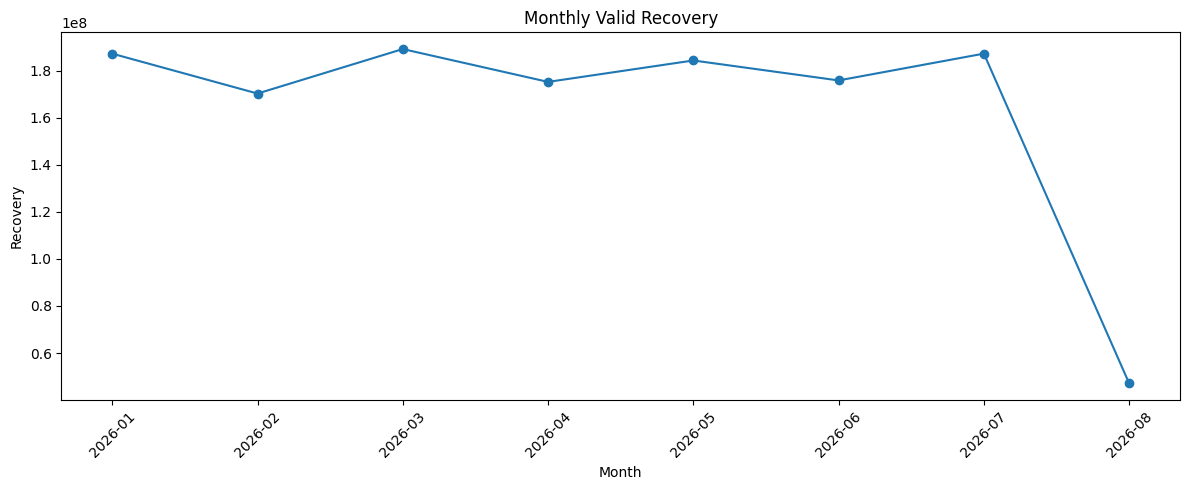

In [337]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    performance["month"],
    performance["recovery"],
    marker="o"
)

plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Recovery")
plt.title("Monthly Valid Recovery")

plt.tight_layout()
plt.show()

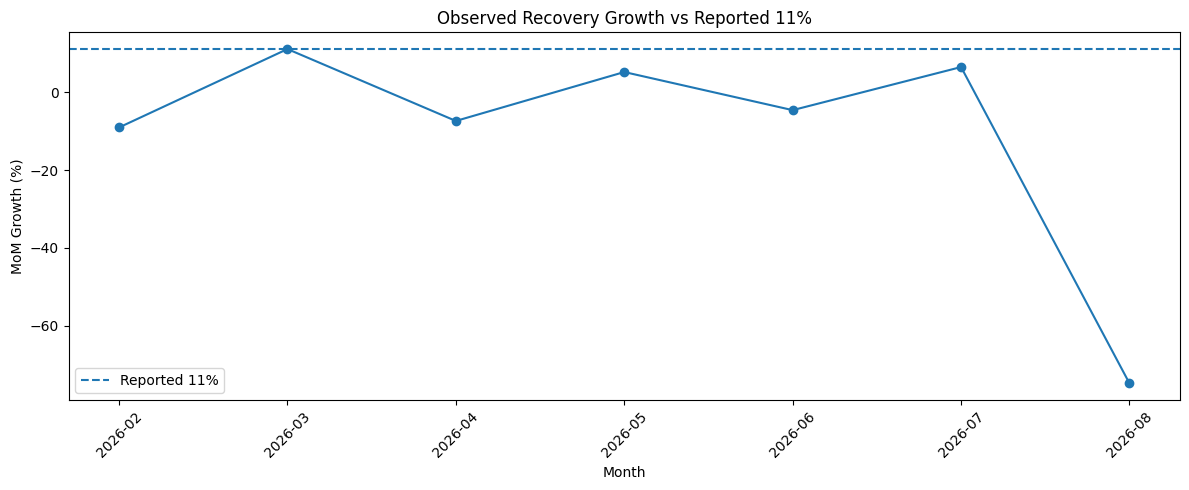

In [338]:
plt.figure(figsize=(12, 5))

plt.plot(
    performance["month"],
    performance["mom_growth_pct"],
    marker="o"
)

plt.axhline(
    11,
    linestyle="--",
    label="Reported 11%"
)

plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("MoM Growth (%)")
plt.title("Observed Recovery Growth vs Reported 11%")
plt.legend()

plt.tight_layout()
plt.show()

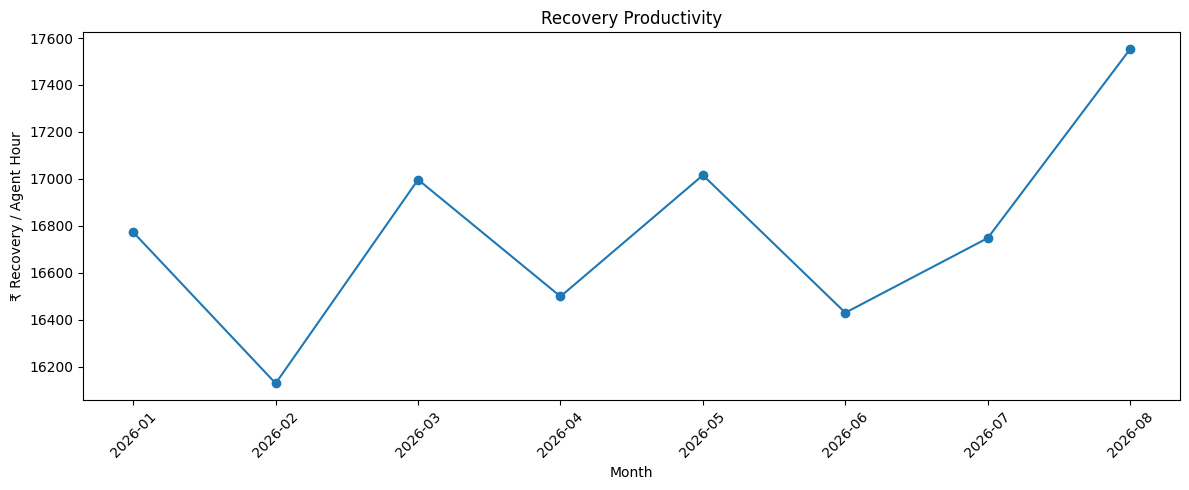

In [339]:
plt.figure(figsize=(12, 5))

plt.plot(
    performance["month"],
    performance["recovery_per_agent_hour"],
    marker="o"
)

plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("₹ Recovery / Agent Hour")
plt.title("Recovery Productivity")

plt.tight_layout()
plt.show()

In [340]:
phase4_summary = pd.DataFrame([
    {
        "metric": "Reported recovery improvement",
        "value": 11
    },
    {
        "metric": "Average observed MoM growth",
        "value": actual_avg_mom
    },
    {
        "metric": "Median observed MoM growth",
        "value": median_mom_growth
    },
    {
        "metric": "Latest month MoM growth",
        "value": latest_growth
    },
    {
        "metric": "First-to-last month growth",
        "value": overall_growth
    },
    {
        "metric": "Overall PTP kept rate",
        "value": overall_ptp_kept_rate
    }
])

display(phase4_summary)

,metric,value
0,Reported recovery improvement,11.000000
1,Average observed MoM growth,-10.441810
2,Median observed MoM growth,-4.601411
3,Latest month MoM growth,-74.840993
4,First-to-last month growth,-74.838480
5,Overall PTP kept rate,49.646096


In [341]:
phase4_summary.to_csv(
    REPORT_DIR / "phase4_performance_summary.csv",
    index=False
)

In [342]:
display(performance)
display(
    pd.crosstab(
        ptp_validation["status"],
        ptp_validation["payment_near_promise"]
    )
)
display(phase4_summary)

,month,recovery,payment_events,accounts_recovered,mom_growth_pct,recovery_per_recovered_account,targeted_accounts,targeting_events,total_calls,contacted_calls,contact_rate,rpc_calls,rpc_rate,ptps,ptp_accounts,rpc_accounts,ptp_rate,resolved_ptps,kept_ptps,ptp_kept_rate,agent_hours,active_agents,recovery_per_targeted_account,recovery_per_agent_hour,recovery_per_active_agent,near_reported_11pct
0,2025-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0.000000,0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1,2026-01,1.872291e+08,2464.0,2374.0,NaN,78866.523837,5732.0,6369.0,12683,2703,21.311992,3790,29.882520,2522.0,2430.0,3070.0,79.153094,1251.0,607.0,48.521183,11162.578611,875.0,32663.839426,16772.928023,213976.145817,False
2,2026-02,1.702796e+08,2268.0,2173.0,-9.052818,78361.534731,5160.0,5709.0,11570,2441,21.097666,3508,30.319793,2220.0,2145.0,2847.0,75.342466,1118.0,567.0,50.715564,10557.011389,871.0,32999.925382,16129.528396,195498.983892,False
3,2026-03,1.891903e+08,2524.0,2419.0,11.105681,78210.139140,5666.0,6290.0,12845,2750,21.409109,3917,30.494356,2509.0,2411.0,3185.0,75.698587,1248.0,619.0,49.599359,11130.820000,878.0,33390.456509,16996.980149,215478.731868,True
4,2026-04,1.752289e+08,2406.0,2304.0,-7.379551,76054.223164,5585.0,6205.0,12241,2539,20.741769,3696,30.193612,2492.0,2376.0,3017.0,78.753729,1256.0,629.0,50.079618,10620.321667,869.0,31374.920353,16499.399516,201644.338516,False
5,2026-05,1.843355e+08,2449.0,2344.0,5.196946,78641.417944,5800.0,6442.0,12746,2754,21.606779,3878,30.425231,2507.0,2413.0,3194.0,75.547902,1286.0,634.0,49.300156,10833.129167,890.0,31781.979941,17015.903791,207118.520966,False
6,2026-06,1.758534e+08,2366.0,2286.0,-4.601411,76926.268530,5535.0,6154.0,12128,2677,22.072889,3582,29.534960,2439.0,2366.0,2939.0,80.503573,1218.0,602.0,49.425287,10703.008611,875.0,31771.174320,16430.282012,200975.371269,False
7,2026-07,1.872478e+08,2441.0,2335.0,6.479478,80191.792719,5666.0,6230.0,12578,2619,20.822070,3684,29.289235,2626.0,2497.0,3016.0,82.791777,1313.0,645.0,49.124143,11180.158611,887.0,33047.623720,16748.227151,211102.408117,False
8,2026-08,4.710970e+07,616.0,608.0,-74.840993,77483.051497,1566.0,1601.0,3210,669,20.841121,1010,31.464174,685.0,678.0,858.0,79.020979,352.0,186.0,52.840909,2683.859722,404.0,30082.819483,17552.964829,116608.156708,False


payment_near_promise,False,True
status,,
BROKEN,4502,51
CANCELLED,4480,63
KEPT,4407,82
OPEN,4353,62


,metric,value
0,Reported recovery improvement,11.000000
1,Average observed MoM growth,-10.441810
2,Median observed MoM growth,-4.601411
3,Latest month MoM growth,-74.840993
4,First-to-last month growth,-74.838480
5,Overall PTP kept rate,49.646096


In [343]:
print(
    "Payment range:",
    recovery_payments["event_at"].min(),
    "to",
    recovery_payments["event_at"].max()
)

Payment range: 2026-01-01 00:14:40 to 2026-08-08 23:50:23


In [344]:
print(
    "Call range:",
    calls["event_at"].min(),
    "to",
    calls["event_at"].max()
)

Call range: 2025-12-29 06:52:37 to 2026-08-12 15:43:05


In [345]:
print(
    "Targeting range:",
    targeting["target_date"].min(),
    "to",
    targeting["target_date"].max()
)

Targeting range: 2026-01-01 00:00:00 to 2026-08-08 00:00:00


In [346]:
monthly_volume = (
    recovery_payments
    .groupby("month")
    .size()
    .reset_index(name="payment_records")
)

display(monthly_volume)

,month,payment_records
0,2026-01,2464
1,2026-02,2270
2,2026-03,2527
3,2026-04,2407
4,2026-05,2450
5,2026-06,2369
6,2026-07,2442
7,2026-08,616


In [347]:
analysis_start = pd.Timestamp("2026-01-01")
analysis_end = pd.Timestamp("2026-08-01")

complete_months = pd.date_range(
    start=analysis_start,
    end=analysis_end,
    freq="MS"
)

complete_months = complete_months[:-1]

print("Complete analysis months:")
print(complete_months)

Complete analysis months:
DatetimeIndex(['2026-01-01', '2026-02-01', '2026-03-01', '2026-04-01',
               '2026-05-01', '2026-06-01', '2026-07-01'],
              dtype='datetime64[ns]', freq='MS')


In [348]:
complete_month_names = (
    complete_months
    .to_period("M")
    .astype(str)
)

monthly_recovery_complete = monthly_recovery[
    monthly_recovery["month"].isin(
        complete_month_names
    )
].copy()

display(monthly_recovery_complete)

,month,recovery,payment_events,accounts_recovered,mom_growth_pct,recovery_per_recovered_account
0,2026-01,1.872291e+08,2464,2374,NaN,78866.523837
1,2026-02,1.702796e+08,2268,2173,-9.052818,78361.534731
2,2026-03,1.891903e+08,2524,2419,11.105681,78210.139140
3,2026-04,1.752289e+08,2406,2304,-7.379551,76054.223164
4,2026-05,1.843355e+08,2449,2344,5.196946,78641.417944
5,2026-06,1.758534e+08,2366,2286,-4.601411,76926.268530
6,2026-07,1.872478e+08,2441,2335,6.479478,80191.792719


In [349]:
monthly_recovery_complete["mom_growth_pct"] = (
    monthly_recovery_complete["recovery"]
    .pct_change() * 100
)

display(
    monthly_recovery_complete[
        [
            "month",
            "recovery",
            "mom_growth_pct"
        ]
    ]
)

,month,recovery,mom_growth_pct
0,2026-01,1.872291e+08,NaN
1,2026-02,1.702796e+08,-9.052818
2,2026-03,1.891903e+08,11.105681
3,2026-04,1.752289e+08,-7.379551
4,2026-05,1.843355e+08,5.196946
5,2026-06,1.758534e+08,-4.601411
6,2026-07,1.872478e+08,6.479478


In [350]:
actual_avg_mom = (
    monthly_recovery_complete["mom_growth_pct"]
    .dropna()
    .mean()
)

print(
    f"Average MoM recovery growth: {actual_avg_mom:.2f}%"
)

Average MoM recovery growth: 0.29%


In [351]:
actual_median_mom = (
    monthly_recovery_complete["mom_growth_pct"]
    .dropna()
    .median()
)

print(
    f"Median MoM recovery growth: {actual_median_mom:.2f}%"
)

Median MoM recovery growth: 0.30%


In [352]:
first_recovery = (
    monthly_recovery_complete.iloc[0]["recovery"]
)

last_recovery = (
    monthly_recovery_complete.iloc[-1]["recovery"]
)

complete_period_growth = (
    (last_recovery - first_recovery)
    / first_recovery
    * 100
)

print(
    f"Jan → Jul recovery growth: "
    f"{complete_period_growth:.2f}%"
)

Jan → Jul recovery growth: 0.01%


In [353]:
monthly_recovery_complete[
    "recovery_per_recovered_account"
] = (
    monthly_recovery_complete["recovery"]
    / monthly_recovery_complete["accounts_recovered"]
)

display(
    monthly_recovery_complete[
        [
            "month",
            "recovery",
            "accounts_recovered",
            "recovery_per_recovered_account"
        ]
    ]
)

,month,recovery,accounts_recovered,recovery_per_recovered_account
0,2026-01,1.872291e+08,2374,78866.523837
1,2026-02,1.702796e+08,2173,78361.534731
2,2026-03,1.891903e+08,2419,78210.139140
3,2026-04,1.752289e+08,2304,76054.223164
4,2026-05,1.843355e+08,2344,78641.417944
5,2026-06,1.758534e+08,2286,76926.268530
6,2026-07,1.872478e+08,2335,80191.792719


In [354]:
performance_complete = (
    monthly_recovery_complete
    .merge(
        targeted_monthly[
            targeted_monthly["month"].isin(
                complete_month_names
            )
        ],
        on="month",
        how="left"
    )
    .merge(
        contact_monthly[
            contact_monthly["month"].isin(
                complete_month_names
            )
        ],
        on="month",
        how="left"
    )
    .merge(
        rpc_monthly[
            rpc_monthly["month"].isin(
                complete_month_names
            )
        ],
        on="month",
        how="left"
    )
    .merge(
        ptp_rate[
            ptp_rate["month"].isin(
                complete_month_names
            )
        ],
        on="month",
        how="left"
    )
    .merge(
        ptp_kept_monthly[
            ptp_kept_monthly["month"].isin(
                complete_month_names
            )
        ],
        on="month",
        how="left"
    )
    .merge(
        monthly_agent_hours[
            monthly_agent_hours["month"].isin(
                complete_month_names
            )
        ],
        on="month",
        how="left"
    )
)

In [355]:
performance_complete[
    "recovery_per_targeted_account"
] = (
    performance_complete["recovery"]
    / performance_complete["targeted_accounts"]
)

performance_complete[
    "recovery_per_agent_hour"
] = (
    performance_complete["recovery"]
    / performance_complete["agent_hours"]
)

performance_complete[
    "recovery_per_active_agent"
] = (
    performance_complete["recovery"]
    / performance_complete["active_agents"]
)

In [356]:
display(
    performance_complete[
        [
            "month",
            "recovery",
            "mom_growth_pct",
            "targeted_accounts",
            "contact_rate",
            "rpc_rate",
            "ptp_rate",
            "ptp_kept_rate",
            "recovery_per_targeted_account",
            "recovery_per_agent_hour"
        ]
    ]
)

,month,recovery,mom_growth_pct,targeted_accounts,contact_rate,rpc_rate,ptp_rate,ptp_kept_rate,recovery_per_targeted_account,recovery_per_agent_hour
0,2026-01,1.872291e+08,NaN,5732,21.311992,29.882520,79.153094,48.521183,32663.839426,16772.928023
1,2026-02,1.702796e+08,-9.052818,5160,21.097666,30.319793,75.342466,50.715564,32999.925382,16129.528396
2,2026-03,1.891903e+08,11.105681,5666,21.409109,30.494356,75.698587,49.599359,33390.456509,16996.980149
3,2026-04,1.752289e+08,-7.379551,5585,20.741769,30.193612,78.753729,50.079618,31374.920353,16499.399516
4,2026-05,1.843355e+08,5.196946,5800,21.606779,30.425231,75.547902,49.300156,31781.979941,17015.903791
5,2026-06,1.758534e+08,-4.601411,5535,22.072889,29.534960,80.503573,49.425287,31771.174320,16430.282012
6,2026-07,1.872478e+08,6.479478,5666,20.822070,29.289235,82.791777,49.124143,33047.623720,16748.227151


In [357]:
performance_complete.to_csv(
    REPORT_DIR / "monthly_performance_complete.csv",
    index=False
)

print(
    "Saved monthly_performance_complete.csv"
)

Saved monthly_performance_complete.csv


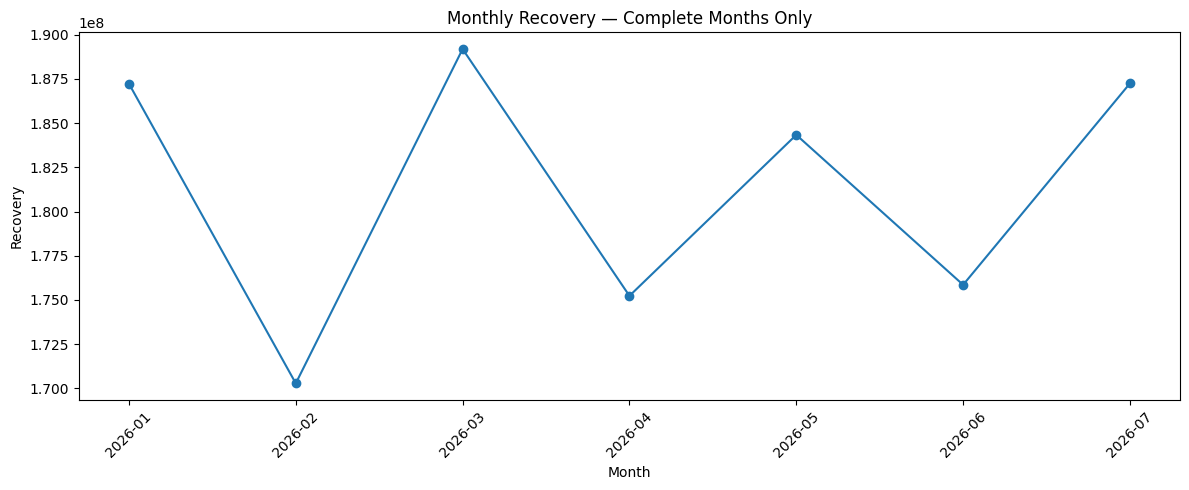

In [358]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    performance_complete["month"],
    performance_complete["recovery"],
    marker="o"
)

plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Recovery")
plt.title("Monthly Recovery — Complete Months Only")

plt.tight_layout()
plt.show()

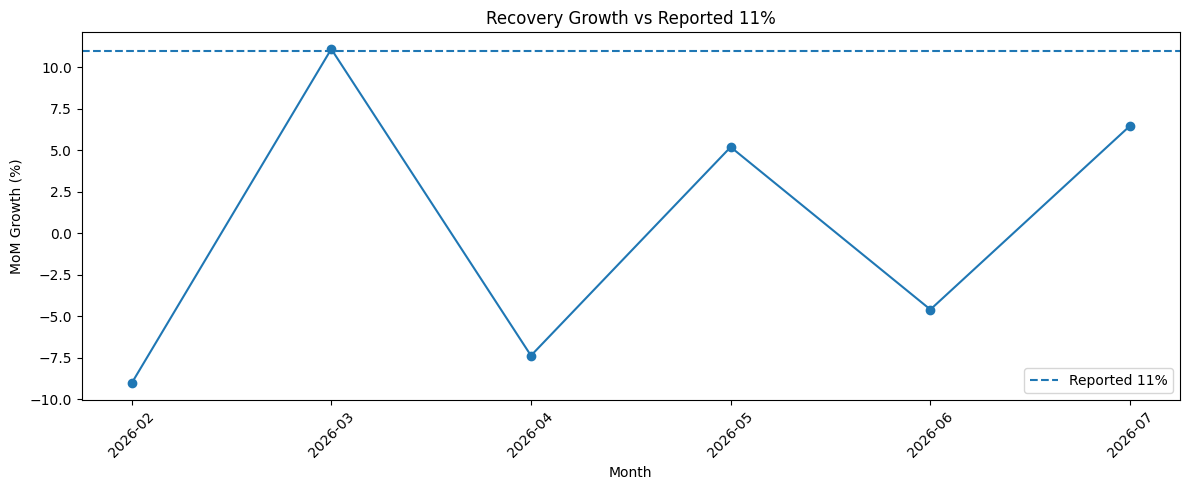

In [359]:
plt.figure(figsize=(12, 5))

plt.plot(
    performance_complete["month"],
    performance_complete["mom_growth_pct"],
    marker="o"
)

plt.axhline(
    11,
    linestyle="--",
    label="Reported 11%"
)

plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("MoM Growth (%)")
plt.title("Recovery Growth vs Reported 11%")

plt.legend()
plt.tight_layout()
plt.show()

In [360]:
claim_assessment = pd.DataFrame([
    {
        "metric": "Reported MoM improvement",
        "reported_value_pct": 11,
        "observed_average_mom_pct": actual_avg_mom,
        "difference_percentage_points":
            actual_avg_mom - 11
    },
    {
        "metric": "Median MoM improvement",
        "reported_value_pct": 11,
        "observed_average_mom_pct": actual_median_mom,
        "difference_percentage_points":
            actual_median_mom - 11
    }
])

display(claim_assessment)

,metric,reported_value_pct,observed_average_mom_pct,difference_percentage_points
0,Reported MoM improvement,11,0.291388,-10.708612
1,Median MoM improvement,11,0.297768,-10.702232


In [361]:
claim_assessment.to_csv(
    REPORT_DIR / "claim_assessment_initial.csv",
    index=False
)

In [362]:
rpc_validation = (
    call_disposition
    .groupby("disposition_code")
    .agg(
        total_calls=("call_id", "nunique"),
        answered_calls=("is_contact", "sum"),
        rpc_calls=("is_rpc", "sum")
    )
    .reset_index()
)

rpc_validation["answered_rate"] = (
    rpc_validation["answered_calls"]
    / rpc_validation["total_calls"]
    * 100
)

rpc_validation["rpc_rate"] = (
    rpc_validation["rpc_calls"]
    / rpc_validation["total_calls"]
    * 100
)

display(rpc_validation)

,disposition_code,total_calls,answered_calls,rpc_calls,answered_rate,rpc_rate
0,CALLBACK,3765,767,3878,20.371846,103.001328
1,DISPUTE,3734,809,3829,21.665774,102.544189
2,NO_CONTACT,3926,804,0,20.478859,0.000000
3,PAID,3725,777,3820,20.859060,102.550336
4,PROMISE_TO_PAY,3843,767,3929,19.958366,102.237835
5,PTP,3807,790,3907,20.751248,102.626740
6,PTP_BROKEN,3820,823,3904,21.544503,102.198953
7,REFUSED,3700,751,3798,20.297297,102.648649
8,WRONG_NUMBER,3851,770,0,19.994807,0.000000


In [363]:
display(
    pd.crosstab(
        call_disposition["call_status"],
        call_disposition["disposition_code"],
        normalize="index"
    ).round(3)
)

disposition_code,CALLBACK,DISPUTE,NO_CONTACT,PAID,PROMISE_TO_PAY,PTP,PTP_BROKEN,REFUSED,WRONG_NUMBER
call_status,,,,,,,,,
ANSWERED,0.109,0.115,0.114,0.110,0.109,0.112,0.117,0.106,0.109
BUSY,0.120,0.104,0.116,0.109,0.112,0.114,0.103,0.107,0.115
FAILED,0.110,0.110,0.115,0.105,0.111,0.112,0.109,0.109,0.119
NO_ANSWER,0.108,0.109,0.121,0.110,0.112,0.109,0.113,0.106,0.112
VOICEMAIL,0.107,0.109,0.107,0.111,0.117,0.111,0.115,0.114,0.109


In [364]:
disposition_per_call = (
    dispositions
    .groupby("call_id")
    .size()
    .reset_index(name="disposition_count")
)

display(
    disposition_per_call[
        disposition_per_call["disposition_count"] > 1
    ].head(20)
)

,call_id,disposition_count
4,CALL0000012,2
6,CALL0000016,2
15,CALL0000062,2
16,CALL0000064,2
19,CALL0000069,2
20,CALL0000071,2
23,CALL0000076,2
32,CALL0000102,2
36,CALL0000112,2
42,CALL0000130,2


In [365]:
print(
    "Total disposition records:",
    len(dispositions)
)

print(
    "Unique calls with dispositions:",
    dispositions["call_id"].nunique()
)

print(
    "Calls with multiple dispositions:",
    (
        disposition_per_call["disposition_count"] > 1
    ).sum()
)

Total disposition records: 35000
Unique calls with dispositions: 28971
Calls with multiple dispositions: 5282


In [366]:
display(
    disposition_per_call[
        "disposition_count"
    ].value_counts().sort_index()
)

disposition_count
1    23689
2     4613
3      596
4       68
5        5
Name: count, dtype: int64

In [367]:
duplicate_call_ids = disposition_per_call[
    disposition_per_call["disposition_count"] > 1
]["call_id"]

display(
    dispositions[
        dispositions["call_id"].isin(
            duplicate_call_ids.head(5)
        )
    ]
    .sort_values(
        ["call_id", "event_at"]
    )
)

,disposition_id,account_id,borrower_id,event_at,call_id,agent_id,disposition_code,disposition_version
29482,DISPOSITION0029483,ACC0000645,BRW0003002,2026-01-30 23:24:04,CALL0000012,AGT0000386,WRONG_NUMBER,v1
25940,DISPOSITION0025941,ACC0011317,BRW0005370,2026-03-25 03:52:02,CALL0000012,AGT0000761,NO_CONTACT,v1
1336,DISPOSITION0001337,ACC0014154,BRW0002077,2026-05-07 02:42:55,CALL0000016,AGT0000337,WRONG_NUMBER,legacy
21457,DISPOSITION0021458,ACC0001590,BRW0006505,2026-05-09 15:05:56,CALL0000016,AGT0000353,WRONG_NUMBER,legacy
32628,DISPOSITION0032629,ACC0002877,BRW0008976,2026-01-01 22:51:02,CALL0000062,AGT0000746,CALLBACK,legacy
24406,DISPOSITION0024407,ACC0014568,BRW0007798,2026-06-30 08:54:12,CALL0000062,AGT0000840,PROMISE_TO_PAY,v2
20936,DISPOSITION0020937,ACC0016244,BRW0007406,2026-01-09 00:29:39,CALL0000064,AGT0000402,REFUSED,legacy
9215,DISPOSITION0009216,ACC0018821,BRW0000239,2026-02-26 23:27:47,CALL0000064,AGT0000682,PTP_BROKEN,legacy
15328,DISPOSITION0015329,ACC0025811,BRW0010984,2026-02-01 02:38:54,CALL0000069,AGT0000741,DISPUTE,v1
15091,DISPOSITION0015092,ACC0005921,BRW0011654,2026-06-09 12:44:17,CALL0000069,AGT0000663,PROMISE_TO_PAY,v2


In [368]:
disp_time = dispositions.copy()

disp_time["event_at"] = pd.to_datetime(
    disp_time["event_at"],
    errors="coerce"
)

display(
    disp_time[
        disp_time["call_id"].isin(
            duplicate_call_ids.head(5)
        )
    ][
        [
            "call_id",
            "event_at",
            "disposition_code",
            "disposition_version"
        ]
    ]
    .sort_values(
        ["call_id", "event_at"]
    )
)

,call_id,event_at,disposition_code,disposition_version
29482,CALL0000012,2026-01-30 23:24:04,WRONG_NUMBER,v1
25940,CALL0000012,2026-03-25 03:52:02,NO_CONTACT,v1
1336,CALL0000016,2026-05-07 02:42:55,WRONG_NUMBER,legacy
21457,CALL0000016,2026-05-09 15:05:56,WRONG_NUMBER,legacy
32628,CALL0000062,2026-01-01 22:51:02,CALLBACK,legacy
24406,CALL0000062,2026-06-30 08:54:12,PROMISE_TO_PAY,v2
20936,CALL0000064,2026-01-09 00:29:39,REFUSED,legacy
9215,CALL0000064,2026-02-26 23:27:47,PTP_BROKEN,legacy
15328,CALL0000069,2026-02-01 02:38:54,DISPUTE,v1
15091,CALL0000069,2026-06-09 12:44:17,PROMISE_TO_PAY,v2


In [369]:
print(
    "Call rows:",
    len(calls)
)

print(
    "Unique call IDs:",
    calls["call_id"].nunique()
)

print(
    "Duplicate call IDs:",
    calls["call_id"].duplicated().sum()
)

Call rows: 90079
Unique call IDs: 90000
Duplicate call IDs: 79


In [370]:
call_times = calls[
    [
        "call_id",
        "event_at"
    ]
].rename(
    columns={"event_at": "call_event_at"}
)

disp_time_check = dispositions.merge(
    call_times,
    on="call_id",
    how="left"
)

disp_time_check["event_at"] = pd.to_datetime(
    disp_time_check["event_at"],
    errors="coerce"
)

disp_time_check["call_event_at"] = pd.to_datetime(
    disp_time_check["call_event_at"],
    errors="coerce"
)

disp_time_check["seconds_after_call"] = (
    disp_time_check["event_at"]
    - disp_time_check["call_event_at"]
).dt.total_seconds()

display(
    disp_time_check["seconds_after_call"]
    .describe()
)

count    3.502700e+04
mean     3.522083e+04
std      7.702178e+06
min     -1.881862e+07
25%     -5.465812e+06
50%      3.274900e+04
75%      5.576664e+06
max      1.893945e+07
Name: seconds_after_call, dtype: float64

In [371]:
print(
    "Dispositions before call:",
    (
        disp_time_check["seconds_after_call"] < 0
    ).sum()
)

print(
    "Dispositions > 24h after call:",
    (
        disp_time_check["seconds_after_call"] > 86400
    ).sum()
)

Dispositions before call: 17457
Dispositions > 24h after call: 17418
